# Bayesian Workflow

In this notebook we will look at an end-to-end example of a Bayesian analysis problem. While the problem itself is simple, it clearly showcases the steps that you need to follow.

**Problem**
Estimate the probability of a coin landing heads (denoted θ) using a Bayesian approach.



In [1]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

The ***first step*** is defining our model. In this case we have a fairly simple model:

$\theta \sim Beta(\alpha, \beta)$

$x_i \sim Bernoulli(\theta)$

What should $\alpha$ and $\beta$ be for the prior? We can explore 3 possibilities:

* $\alpha=1$ and $\beta=1$. This in an uninformative prior and corresponds to the uniform distribution and we basically "declare" complete ignorance about the status of the coin before hand. We give equal probability of being completely biased (e.g., $\theta = 0.999$ or $\theta = 0.001$) or being unbiased (e.g., $\theta = 0.5$).
* $\alpha = 5$ and $\beta=5$. This corresponds to a distribution that is centered around 0.5 but they are weakly informative, pulling away from extreme values of 0 and 1. Shows a *preference* for moderate bias as compared to equally probable biases like the previous prior.
* $\alpha = 30$ and $\beta = 30$. This corresponds to a prior that expresses strong belief. This prior is centered around 0.5 and is narrow, favoring more a model without any model bias.

For now we will start with assuming complete ignorance for the coin. We found that coin on the street and it could as well be a magician's coin for getting always heads. So we will assume a prior of $Beta(1,1)$. In the same vein, a prior $Beta(5,5)$ can be described as "I think it's a regular coin, but I'm not 100% sure", while a $Beta(30,30)$ essentially says "I’m very confident the coin is fair. It's minted at a casino".

Our next, ***second step*** is performing **prior predictive checks**. This  entails checks on whether the prior distribution can generate data that are plausible. While you might think that since we chose a non informative prior this check is not important - since whatever data I simulate with this prior will not show any pattern - there are reasons to still do them.

1. Non informative does not mean neutral in all contexts. For example, $Beta(1,1)$ as we saw allows extremes with the same probability as it allows fair coins. If your true (lack of) knowledge is more "I think the coin is probably not completely biased", then the prior predictive checks might led you to understanding that a $Beta(1,1)$ might be too extreme of a choice. So prior predictive checks can help you answer "*Is this level of non-commitment too extreme?*".
2. These checks allows you to clarify the assumptions. Even when you think “I have no idea,” prior predictive checks force you to confront:
    * What your prior really implies
    * What "no idea" looks like in simulated data
    * Whether that’s defensible

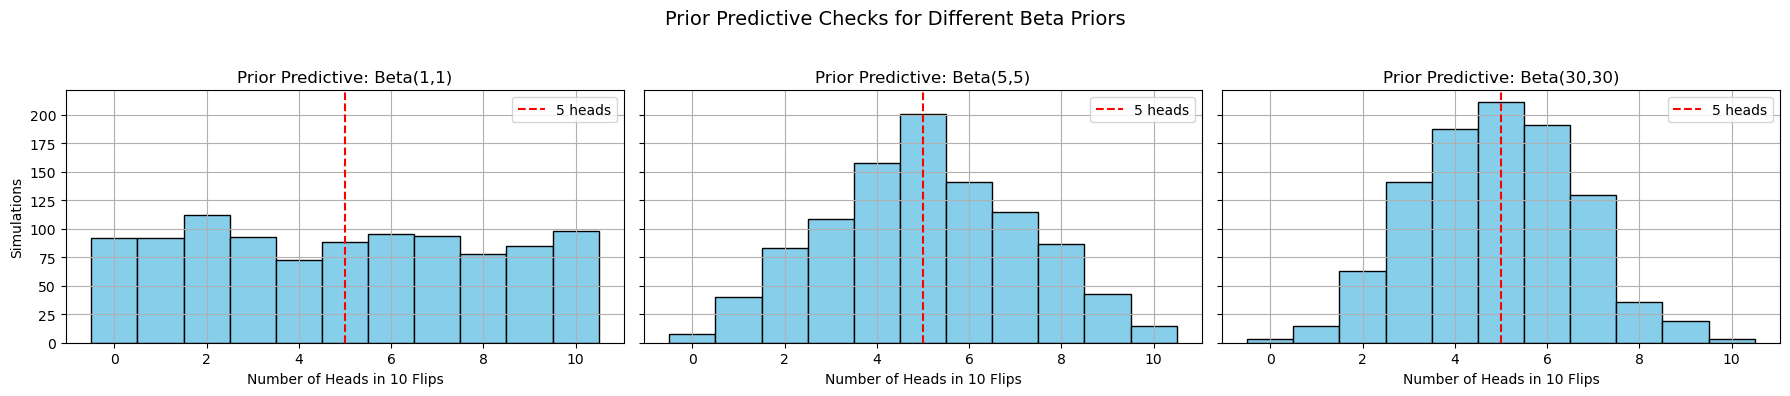

In [2]:
# Settings
num_simulations = 1000
flips_per_simulation = 10
theta_range = np.linspace(0, 1, 200)

# Different priors
priors = {
    "Beta(1,1)": (1, 1),
    "Beta(5,5)": (5, 5),
    "Beta(30,30)": (30, 30)
}

# Prepare plot
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (label, (a, b)) in zip(axes, priors.items()):
    # Sample theta from the prior
    theta_sim = np.random.beta(a, b, size=num_simulations)
    # Simulate 10 coin flips for each theta
    heads_counts = np.random.binomial(n=flips_per_simulation, p=theta_sim)

    # Plot histogram of number of heads
    ax.hist(heads_counts, bins=np.arange(0, 12) - 0.5, edgecolor='black', color='skyblue')
    ax.axvline(5, color='red', linestyle='--', label="5 heads")
    ax.set_title(f"Prior Predictive: {label}")
    ax.set_xlabel("Number of Heads in 10 Flips")
    ax.legend()
    ax.grid(True)

axes[0].set_ylabel("Simulations")
plt.suptitle("Prior Predictive Checks for Different Beta Priors", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


After looking at these graphs, it might be more advisable to go with a weakly informative prior, $Beta(5,5)$.

Now that we have our prior, the ***third step*** is collecting data. In our case we flip the coin 20 times and record the number of heads (1) and number of tails (0) that we got.

In [3]:
data = [1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1]

Next (***fourth step***) is the posterior inference. In this case we have conjugacy and we can obtain the posterior analytically as:

$\theta |x \sim Beta(\alpha + \#~of ~heads, \beta + \# ~of ~tails) = Beta(19,11)$

However, here we will sample the posterior using MCMC, since this is what we will have to do in the majority of the cases where the models will be more complex.

In [4]:
import arviz as az

with pm.Model() as coin_model:
    theta = pm.Beta("theta", alpha=5, beta=5)
    obs = pm.Bernoulli("obs", p=theta, observed=data)
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)

az.summary(trace, var_names=["theta"], round_to=4)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.6319,0.0873,0.4684,0.793,0.0021,0.0015,1794.779,2717.6862,0.9995


array([[<AxesSubplot: title={'center': 'theta'}>,
        <AxesSubplot: title={'center': 'theta'}>]], dtype=object)

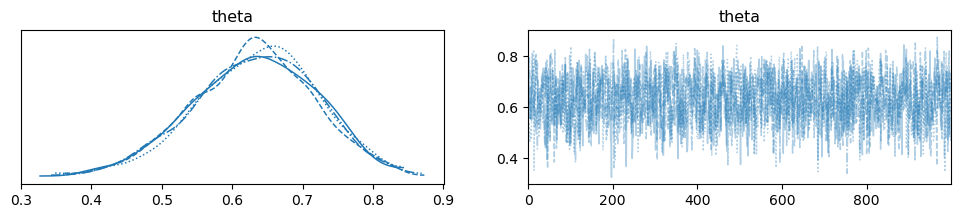

In [5]:
az.plot_trace(trace, var_names=["theta"])

The ***fifth step*** includes performing posterior predictive checks. Similar to the prior predictive checks, we simulate data with our model and the posterior infered and we want to examine whether they are *similar* with the data we observed. There are many several checks we can do, such as for summary statistics (mean, median, variance etc.). Here we will simply use the posterior predictive distribution to see how many times we will get heads in several 20-coin flips.

In [6]:
with coin_model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["obs"])


Sampling: [obs]


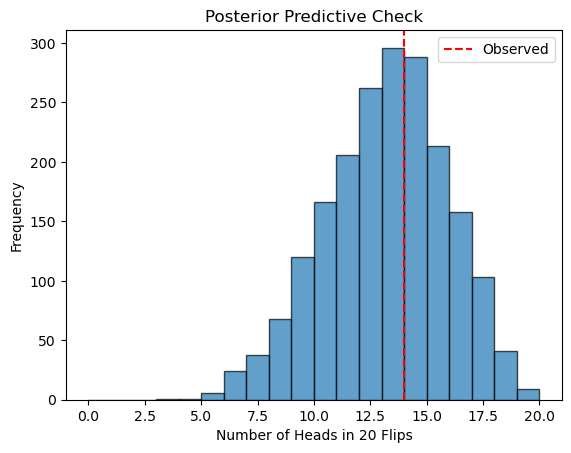

In [7]:
import matplotlib.pyplot as plt

# Sum of heads for each simulated dataset
simulated_totals_0 = ppc.posterior_predictive["obs"][0].sum(axis=1)
simulated_totals_1= ppc.posterior_predictive["obs"][1].sum(axis=1)



# Compare to observed total (e.g., 14 heads)
plt.hist(np.concatenate([simulated_totals_0, simulated_totals_1]), bins=range(21), alpha=0.7, edgecolor="black")
plt.axvline(14, color="red", linestyle="--", label="Observed")
plt.xlabel("Number of Heads in 20 Flips")
plt.ylabel("Frequency")
plt.legend()
plt.title("Posterior Predictive Check")
plt.show()


As we can see, the true observed value (of 14 heads) is right within the mass of the simulated data, supporting the consistency of our posterior predictive with the observed data.

At this ***sixth step***, we usually take a moment to reflect for our model and then refine it if needed. For example, should we change the prior? Should we remove the assumption that every coin flip is i.i.d.? This could be because the initial angle of spin is important, or because the initial side up is important. Or we might flipped the first 10 with our left hand and the next 10 with our right.

In our case most probably our model is fine - but these are questions we should be asking at that phase of the project

In the next, ***seventh step***, we compare the models with other competitors. While in our case there is not really need to do this, we will compare our model with another one that uses a strong prior, $Beta(30,30)$. We will perform LOO evaluation.

In [8]:
# Model A: Beta(5,5)
with pm.Model() as model_a:
    theta = pm.Beta("theta", alpha=5, beta=5)
    obs = pm.Bernoulli("obs", p=theta, observed=data)
    trace_a = pm.sample(1000, tune=1000, return_inferencedata=True,idata_kwargs={'log_likelihood':True})

# Model B: Beta(30,30)
with pm.Model() as model_b:
    theta = pm.Beta("theta", alpha=30, beta=30)
    obs = pm.Bernoulli("obs", p=theta, observed=data)
    trace_b = pm.sample(1000, tune=1000, return_inferencedata=True,idata_kwargs={'log_likelihood':True})


# Compare models using leave-one-out (LOO)
model_compare = az.compare({"Beta(5,5)": trace_a, "Beta(30,30)": trace_b})
model_compare

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
"Beta(5,5)",0,-13.075116,0.658347,0.000000,0.998671,1.201935,0.000000,False,log
"Beta(30,30)",1,-13.384809,0.238033,0.309692,0.001329,0.431533,0.770402,False,log


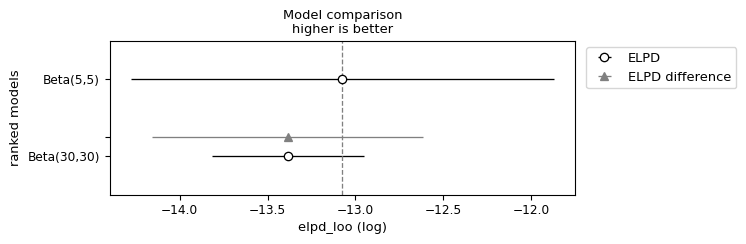

In [9]:
az.plot_compare(model_compare, insample_dev=False);


Looking at these results we can say that our original model performs better (with regards to ``elpd_loo``). The ``weights`` can be thought of as the probability of the model being true, and we can see that our original model is much more probable.  

Next the ***final steps*** involve summarizing the posterior and communicating the results. This step of course depends a lot on who you are communicating the results. If they are technically versed you can present technical details, if not, you want to just keep the high level message.

One good idea (for the technically inclined) is to plot the prior and the posterior. This will show visually whether the model has learned something from the data. You can also show the posterior mean and the credible intervals. In general, anything that is relevant to the way that the model is supposed to be used for downstream tasks.

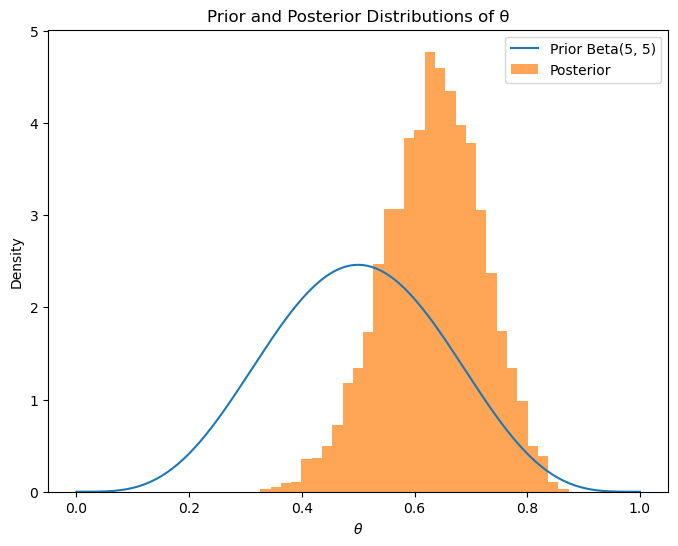

In [10]:
from scipy.stats import beta

# Prior distribution
prior_alpha = 5
prior_beta = 5
x = np.linspace(0, 1, 200)
prior_dist = beta(prior_alpha, prior_beta)
prior_pdf = prior_dist.pdf(x)

# Posterior distribution from the provided code (assuming 'trace' is the posterior samples)
posterior_samples = trace.posterior["theta"].values.flatten()  # Access the posterior samples

# Plot the prior and posterior distributions
plt.figure(figsize=(8, 6))
plt.plot(x, prior_pdf, label="Prior Beta(5, 5)")
plt.hist(posterior_samples, bins=30, density=True, alpha=0.7, label="Posterior")  # Plot posterior as a histogram
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.title("Prior and Posterior Distributions of θ")
plt.legend()
plt.show()


***What if you decided to flip the coin 20 more times. This time you get 10 heads and 10 tails. What is your new posterior? ***

In [11]:
data = data + [0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0]

In [12]:
with pm.Model() as coin_model:
    theta = pm.Beta("theta", alpha=5, beta=5)
    obs = pm.Bernoulli("obs", p=theta, observed=data)
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)

az.summary(trace, var_names=["theta"], round_to=4)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.5791,0.0696,0.452,0.7098,0.0017,0.0012,1649.4617,3028.5855,1.005


array([[<AxesSubplot: title={'center': 'theta'}>,
        <AxesSubplot: title={'center': 'theta'}>]], dtype=object)

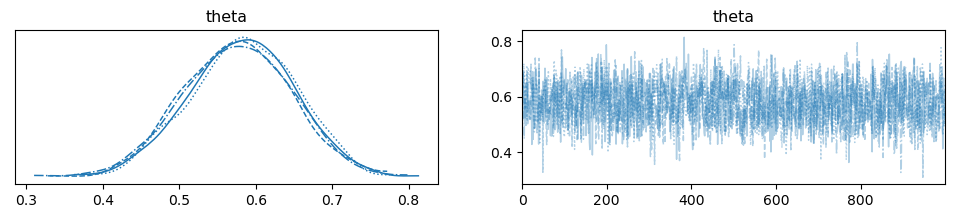

In [13]:
az.plot_trace(trace, var_names=["theta"])

Sampling: [obs]


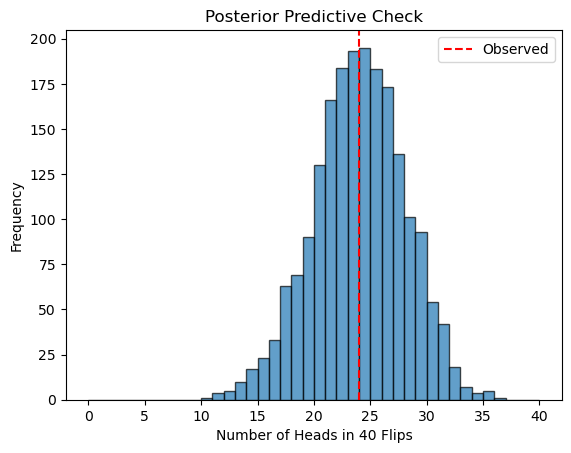

In [14]:
with coin_model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["obs"])


# Sum of heads for each simulated dataset
simulated_totals_0 = ppc.posterior_predictive["obs"][0].sum(axis=1)
simulated_totals_1= ppc.posterior_predictive["obs"][1].sum(axis=1)



# Compare to observed total (e.g., 14+10 heads)
plt.hist(np.concatenate([simulated_totals_0, simulated_totals_1]), bins=range(41), alpha=0.7, edgecolor="black")
plt.axvline(24, color="red", linestyle="--", label="Observed")
plt.xlabel("Number of Heads in 40 Flips")
plt.ylabel("Frequency")
plt.legend()
plt.title("Posterior Predictive Check")
plt.show()
